In [6]:
import os, random
import chess
import chess.pgn
from io import TextIOWrapper
def collect_fens_from_pgn(pgn_path, num_fens=1000000):
    with open(pgn_path, "r", encoding="utf-8", errors="ignore") as f:
        fens = set()
        while len(fens) < num_fens:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            board = game.board()
            for move in game.mainline_moves():
                board.push(move)
                fens.add(board.fen())
                if len(fens) >= num_fens:
                    break
        return list(fens)
    
pgn_file = "test.pgn"  # After manual decompression
fens = collect_fens_from_pgn(pgn_file)
print(f"Collected {len(fens)} FENs. Sample:")
for idx, fen in enumerate(fens[:1000], 1):
    print(f"{idx}. {fen}")


import json
with open("positions.json", "w") as f:
    json.dump({"fens": fens}, f)


Collected 1000000 FENs. Sample:
1. 8/pp6/4p2k/3pK3/5P2/2p1r3/8/6R1 w - - 0 47
2. 2r2rk1/p2q1pbp/2n3p1/1pp5/1n1pP1b1/1P1P1NP1/PB1NQPBP/R4RK1 w - - 6 18
3. 3r4/p5pp/5p2/4pk2/4n3/4n3/P4PPP/1R4K1 w - - 0 31
4. r4rk1/1p3ppp/2ppn2n/4p3/p3P2q/PBPPP2P/1P2QRPN/5RK1 w - - 0 19
5. r1bqk2r/ppppppbp/2n2np1/8/4P3/3P1PP1/PPP3BP/RNBQK1NR b KQkq - 0 5
6. rnbqkbnr/2p2p2/pp1pp1pp/8/2PPP3/2NBB3/PP3PPP/R2QK1NR w KQkq - 0 7
7. 8/1p4p1/1np3k1/4p2N/2P3P1/1P5P/r4P2/4R1K1 b - - 3 29
8. 2N3k1/2p2pP1/4p1bP/p1R5/5P2/1P1P4/1PP1P2R/2K5 b - - 0 34
9. 8/1p6/p1p1p3/4P1Rk/1P1P1n1P/P5R1/5r2/7K b - - 4 43
10. r2qk2r/pppbbppp/2np1n2/1B2p3/3PP3/2N2N2/PPP2PPP/R1BQ1RK1 w kq - 3 7
11. r4r1k/ppp3pp/1b6/4Q3/8/2PqPPBP/PP1N2P1/3RR1K1 b - - 6 24
12. r1bq1rk1/pp2bppp/2n2n2/2pp4/5PP1/3P3P/PPP2Q2/RNBK1BNR b - - 3 9
13. r3k1nr/2pb1p1p/p3p1p1/1p2b1B1/8/1BN5/PPP2PPP/R3K2R w KQkq - 0 13
14. r3r1k1/p5p1/1p3p1p/2pbP3/5P1b/1P1BB2P/P1P1R1P1/R5K1 w - - 0 20
15. 8/8/8/p1p1kp1p/3p1N1b/1K1P4/1PP5/8 w - - 2 51
16. rn1qk2r/pp4pp/3bb3/3p1p2/3P4/1QPB

In [10]:
import numpy as np
import chess
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from stockfish import Stockfish
from tqdm import tqdm
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping
EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
class TQDMProgressBar(Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        print(f"\nTraining for {self.epochs} epochs...\n")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_progress = tqdm(
            total=self.params['steps'],
            desc=f"Epoch {epoch+1}/{self.epochs}",
            unit="batch"
        )

    def on_batch_end(self, batch, logs=None):
        self.epoch_progress.update(1)

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_progress.close()

    def on_train_end(self, logs=None):
        print("\nTraining complete.")

stockfish = Stockfish(path="D:\Check_Matie-SOC-2025\stockfish\stockfish-windows-x86-64-avx2.exe",depth = 2)
# 1) BOARD → TENSOR
# ================

# 2) MODEL DEFINITION
# ===================

# 3) DATASET SETUP & SPLIT
# ========================
# Example data—replace X_data, y_data with your real arrays
N = len(fens)
n1 = 0
n2 =0

def get_y_data(fen):
    global n2
    n2+=1
    if(n2%10000==0):
        print(n2)
    stockfish.set_fen_position(fen)
    eval_info = stockfish.get_evaluation()
    # Handle mates or bad returns
    if eval_info['type'] == 'mate':
        return 10.0 if eval_info['value'] > 0 else -10.0
    elif eval_info['type'] == 'cp':
        return np.clip(eval_info['value'] / 100.0, -10, 10)
    else:
        return 0.0  # default if eval fails
y_data = np.array([get_y_data(fen) for fen in fens])  # in [-10, +10]



10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000


In [4]:
data = y_data.tolist()
with open("ydata.json", "w") as f:
    json.dump({"y_data": data}, f)

NameError: name 'y_data' is not defined

In [5]:

# def gen_x_data(fen: str) -> np.ndarray:
#     board = chess.Board(fen)

#     # 1) Piece positions → 8×8×12
#     #    planes 0–5 = White {P,N,B,R,Q,K}, 6–11 = Black {p,n,b,r,q,k}
#     piece_map = {
#         chess.PAWN:   0,
#         chess.KNIGHT: 1,
#         chess.BISHOP: 2,
#         chess.ROOK:   3,
#         chess.QUEEN:  4,
#         chess.KING:   5,
#     }
#     pieces = np.zeros((8, 8, 12), dtype=np.int8)
#     for sq in chess.SQUARES:
#         p = board.piece_at(sq)
#         if p:
#             base = piece_map[p.piece_type]
#             plane = base + (0 if p.color == chess.WHITE else 6)
#             r, c = divmod(sq, 8)
#             pieces[7-r, c, plane] = 1

#     # 2) Attack maps → 8×8×2
#     #    plane 12 = count of White attackers; 13 = count of Black attackers
#     attack_w = np.zeros((8, 8), dtype=np.int8)
#     attack_b = np.zeros((8, 8), dtype=np.int8)
#     for sq in chess.SQUARES:
#         r, c = divmod(sq, 8)
#         attack_w[7-r, c] = len(board.attackers(chess.WHITE, sq))
#         attack_b[7-r, c] = len(board.attackers(chess.BLACK, sq))

#     # stack into final tensor
#     # shape becomes (8, 8, 12 + 2) = (8, 8, 14)
#     tensor = np.concatenate([
#         pieces,
#         attack_w[:, :, None],
#         attack_b[:, :, None],
#     ], axis=-1)

#     return tensor.astype(np.float32)
import os, random
import chess
import chess.pgn
from io import TextIOWrapper
import numpy as np
import chess
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from stockfish import Stockfish
from tqdm import tqdm
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping
k =0
def gen_x_data(fen):
    global k
    board = chess.Board(fen)
    k+=1
    if(k%10000==0):
        print(k)
    # 1. Piece positions: 8×8×12
    x = np.zeros((8, 8, 12), dtype=np.int8)
    piece_map = {
        chess.PAWN: 0,
        chess.KNIGHT: 1,
        chess.BISHOP: 2,
        chess.ROOK: 3,
        chess.QUEEN: 4,
        chess.KING: 5
    }

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            plane = piece_map[piece.piece_type] + (0 if piece.color == chess.WHITE else 6)
            x[square // 8, square % 8, plane] = 1

    # 2. Castling rights: 8×8×4
    castling = np.zeros((8, 8, 4), dtype=np.int8)
    if board.has_kingside_castling_rights(chess.WHITE): castling[:, :, 0] = 1
    if board.has_queenside_castling_rights(chess.WHITE): castling[:, :, 1] = 1
    if board.has_kingside_castling_rights(chess.BLACK): castling[:, :, 2] = 1
    if board.has_queenside_castling_rights(chess.BLACK): castling[:, :, 3] = 1

    # 3. En passant target square: 8×8×1
    en_passant = np.zeros((8, 8, 1), dtype=np.int8)
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        en_passant[row, col, 0] = 1

    # 4. Whose turn: 8×8×1 (white = 1, black = 0)
    turn = np.ones((8, 8, 1), dtype=np.int8) * int(board.turn)

    # 5. Halfmove clock: 8×8×1 (normalized)
    halfmove = np.ones((8, 8, 1), dtype=np.float32) * min(board.halfmove_clock / 100.0, 1.0)

    # 6. Fullmove number: 8×8×1 (normalized)
    fullmove = np.ones((8, 8, 1), dtype=np.float32) * min(board.fullmove_number / 100.0, 1.0)

    # Concatenate all features into final tensor
    tensor = np.concatenate([x, castling, en_passant, turn, halfmove, fullmove], axis=-1)
    return tensor.astype(np.float32)  # output shape: (8, 8, 20)


# def gen_x_data(fen):
#     global n1
#     n1+=1
#     print(n1)
#     board = chess.Board(fen)
#     return board_to_tensor(board)

# X_data = np.array([gen_x_data(fen) for fen in fens])

In [6]:
import json
import pandas as pd
with open('positions.json', 'r') as file:
    pos = json.load(file)
with open('ydata.json', 'r') as file:
    y = json.load(file)

x_data = np.stack([gen_x_data(fen) for fen in pos['fens']])
y_data = np.stack(y['y_data'])

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000


In [7]:
np.save("xdata.npy", x_data)

In [11]:
import tensorflow as tf
print("TF version:", tf.__version__)                # e.g. 2.19.0
print("Built with CUDA:", tf.test.is_built_with_cuda())  # should be True
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.10.1
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, LeakyReLU,
    Dense, Dropout, add, GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import Policy, set_global_policy
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# Assume x_data and y_data are already loaded in memory
# Example shapes for demonstration:
# x_data = np.random.rand(1000000, 8, 8, 20).astype('float32')
# y_data = np.random.rand(1000000, 1).astype('float32')

# ========================================
# 1) Set Mixed-Precision Policy
# ========================================
policy = Policy("mixed_float16")
set_global_policy(policy)

# ========================================
# 2) Normalize Target Variable (y_data)
# ========================================
mean_y = y_data.mean()
std_y = y_data.std()
y_data_normalized = (y_data - mean_y) / std_y
print(f"Target mean: {mean_y:.4f}, std: {std_y:.4f}")

# Ensure y_data has the correct 2D shape (n_samples, 1)
if y_data_normalized.ndim == 1:
    y_data_normalized = y_data_normalized.reshape(-1, 1)

# ========================================
# 3) Split Data into Training and Validation Sets
# ========================================
val_frac = 0.1
x_train, x_val, y_train, y_val = train_test_split(
    x_data, y_data_normalized, test_size=val_frac, random_state=42
)
print(f"Training samples: {len(x_train):,}")
print(f"Validation samples: {len(x_val):,}")



Target mean: 0.1324, std: 3.7379
Training samples: 900,000
Validation samples: 100,000


Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 8, 8, 20)]   0           []                               
                                                                                                  
 conv2d_85 (Conv2D)             (None, 8, 8, 128)    23168       ['input_6[0][0]']                
                                                                                                  
 batch_normalization_85 (BatchN  (None, 8, 8, 128)   512         ['conv2d_85[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 leaky_re_lu_90 (LeakyReLU)     (None, 8, 8, 128)    0           ['batch_normalization_85[0]

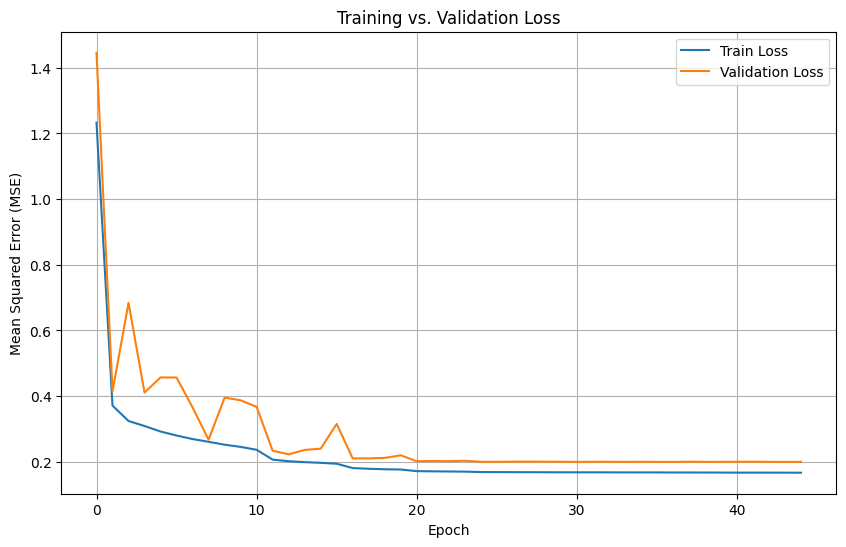


Model saved to chess_eval_resnet_trained.keras


In [ ]:
# ========================================
# 4) Create Keras Sequence for Data Handling
# ========================================
# FIXED: Replaced the tf.data pipeline with a robust tf.keras.utils.Sequence.
# This is the standard Keras way to handle large datasets and avoids
# common generator-related errors.
class ChessDataSequence(Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size

    def __len__(self):
        # Returns the number of batches per epoch
        return int(np.ceil(len(self.x) / self.batch_size))

    def __getitem__(self, idx):
        # Generates one batch of data
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]
        return batch_x, batch_y

batch_size = 4096
INPUT_SHAPE = x_data.shape[1:]

# Instantiate the sequence for training and validation
train_sequence = ChessDataSequence(x_train, y_train, batch_size)
val_sequence = ChessDataSequence(x_val, y_val, batch_size)


# ========================================
# 5) Build ResNet-style Model 🧠
# ========================================
def build_residual_block(x, filters, kernel_size=3):
    """Builds a residual block with two convolutional layers."""
    y = Conv2D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-5))(x)
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)
    y = Conv2D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-5))(y)
    y = BatchNormalization()(y)
    y = add([x, y]) # Skip connection
    y = LeakyReLU()(y)
    return y

def build_model(input_shape, num_res_blocks=8, filters=128):
    """Builds the complete ResNet-style model."""
    inputs = Input(shape=input_shape)
    # Input Stem
    x = Conv2D(filters, 3, padding='same', kernel_regularizer=l2(1e-5))(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    # Residual Tower
    for _ in range(num_res_blocks):
        x = build_residual_block(x, filters)
    # Value Head
    vh = GlobalAveragePooling2D()(x)
    vh = Dense(256, kernel_regularizer=l2(1e-5))(vh)
    vh = LeakyReLU()(vh)
    vh = Dropout(0.5)(vh)
    outputs = Dense(1, activation='linear', dtype='float32', name='value')(vh)
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model(INPUT_SHAPE)
model.summary()

# ========================================
# 6) Compile the Model
# ========================================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss="mse")

# ========================================
# 7) Define Callbacks
# ========================================
log_dir = os.path.join("logs", tf.timestamp().numpy().astype(str))
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    TensorBoard(log_dir=log_dir, update_freq='epoch')
]

# ========================================
# 8) Train the Model ♟️
# ========================================
# Pass the sequence objects directly to model.fit()
# Set verbose=1 to see the standard Keras progress bar.
history = model.fit(
    train_sequence,
    epochs=50,
    validation_data=val_sequence,
    callbacks=callbacks,
    verbose=1
)

# ========================================
# 9) Plot Loss and Save the Model
# ========================================
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

model.save("chess_eval_resnet_trained.keras")

print("\nModel saved to chess_eval_resnet_trained.keras")

# To use the model for predictions:
# y_pred_normalized = model.predict(some_x_data)
# y_pred_original = y_pred_normalized * std_y + mean_y


In [31]:
model.save("chess_eval_resnet_trained.h5", save_format='h5')

Dataset has 1,091,078 positions
Epoch 1/30
1918/1918 [==============================] - 104s 53ms/step - loss: 1.0283 - val_loss: 1.0183
Epoch 2/30
1918/1918 [==============================] - 84s 43ms/step - loss: 1.0023 - val_loss: 1.0167
Epoch 3/30
1918/1918 [==============================] - 87s 45ms/step - loss: 0.9841 - val_loss: 0.9552
Epoch 4/30
1918/1918 [==============================] - 85s 43ms/step - loss: 0.9695 - val_loss: 0.9559
Epoch 5/30
1918/1918 [==============================] - 100s 51ms/step - loss: 0.9623 - val_loss: 1.0224
Epoch 6/30
1918/1918 [==============================] - 95s 49ms/step - loss: 0.9578 - val_loss: 0.9334
Epoch 7/30
1918/1918 [==============================] - 88s 45ms/step - loss: 0.9541 - val_loss: 0.9436
Epoch 8/30
1918/1918 [==============================] - 82s 42ms/step - loss: 0.9509 - val_loss: 0.9529
Epoch 9/30
1918/1918 [==============================] - 86s 44ms/step - loss: 0.9489 - val_loss: 0.9520
Epoch 10/30
1918/1918 [=======

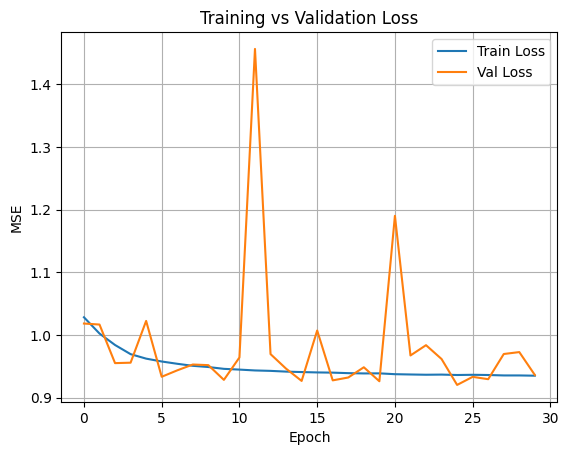

In [71]:
import os
import numpy as np
import pandas as pd
import chess
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, LeakyReLU,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import matplotlib.pyplot as plt
from tensorflow.keras.mixed_precision import Policy, set_global_policy

# 1) Choose the mixed‑precision policy
policy = Policy("mixed_float16")

# 2) Enable it globally
set_global_policy(policy)
# ========================================
# 0) Enable mixed‑precision (TF 2.10)
# ========================================
from tensorflow.keras.mixed_precision import Policy, set_global_policy
policy = Policy('mixed_float16')
set_global_policy(policy)

# ========================================
# 1) Discover dataset size (N)
# ========================================
df_meta = pd.read_csv("positions.csv", usecols=["fen"])
N = len(df_meta)
print(f"Dataset has {N:,} positions")

# ========================================
# 2) Load memmaps for X and Y
# ========================================
X_data = np.memmap(
    "x_data.memmap", mode="r", dtype="float32",
    shape=(N, 8, 8, 14)
)
y_data = np.memmap(
    "y_data.memmap", mode="r", dtype="float32",
    shape=(N, 1)
)

# ========================================
# 3) Normalize targets
# ========================================
mean_y = y_data.mean()
std_y  = y_data.std()
y_data = (y_data - mean_y) / std_y

# ========================================
# 4) Split train / validation indices
# ========================================
val_frac = 0.1
idxs     = np.random.permutation(N)
n_val    = int(N * val_frac)
train_idx = idxs[n_val:]
val_idx   = idxs[:n_val]

# ========================================
# 5) Build tf.data.Dataset via generator
# ========================================
def make_ds(X_mem, y_mem, indices, batch_size, shuffle=False):
    def gen():
        for i in indices:
            yield X_mem[i], y_mem[i]
    output_sig = (
        tf.TensorSpec(shape=(8,8,14), dtype=tf.float32),
        tf.TensorSpec(shape=(1,),     dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(gen, output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(buffer_size=20_000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

batch_size = 512
train_ds = make_ds(X_data, y_data, train_idx, batch_size, shuffle=True)
val_ds   = make_ds(X_data, y_data, val_idx,   batch_size, shuffle=False)

# ========================================
# 6) Build your model
# ========================================
model = Sequential([
    Conv2D(64, 3, padding='same', input_shape=(8,8,14),
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(), LeakyReLU(),

    Conv2D(128, 3, padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), LeakyReLU(),

    Conv2D(128, 3, padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), LeakyReLU(),
    Dropout(0.35),

    GlobalAveragePooling2D(),
    Dense(256, kernel_regularizer=l2(1e-4)),
    LeakyReLU(), 
    Dropout(0.6),

    Dense(1, dtype='float32')  # ensure output is float32
])

model.compile(
    optimizer="adam",
    loss="mse"
)

# ========================================
# 7) Callbacks: EarlyStopping + TensorBoard
# ========================================
log_dir = os.path.join("logs", tf.timestamp().numpy().astype(str))
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    TensorBoard(log_dir=log_dir, update_freq='epoch')
]

# ========================================
# 8) Train
# ========================================
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

# ========================================
# 9) Plot loss curves
# ========================================
plt.figure()
plt.plot(history.history['loss'],  label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# ========================================
# 10) Save final model
# ========================================
model.save("chess_eval_memmap_trained_mixed.keras")

# ========================================
# To invert normalization on predictions:
# y_pred = model.predict(some_ds)
# y_original = y_pred * std_y + mean_y
# ========================================


In [34]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras as keras
mini = 1000000
p = 0
p2 =0

model = keras.models.load_model(f"chess_eval2.keras")
h5_path = r"D:/Check_Matie-SOC-2025/Neural Network/chess_eval_resnet_trained.h5"
model.save(h5_path, save_format='h5')
for i in range(0, 100):
    fen = pos['fens'][i]
    board = chess.Board(fen)

    input_tensor = gen_x_data(fen)
    input_tensor = np.expand_dims(input_tensor, axis=0) 
    score = model.predict(input_tensor)[0, 0]
    a = score
    b = y_data[i]
    print(a,b)
    p+=(a-b)
    p2+=(a-b)**2/a**2

p = p/1000
p2 /=1000
print(p)
print(p2)

# std = p2 - (p)**2/100
# print(std)
# for i in range(1,5):
#     for j in range(2,5):
#         p = 0
#         p2 =0
#         model = keras.models.load_model(f"chess_eval_batch{batch_size}_epochs{epochs}.keras")
#         for fen in fens[:100]:
#             board = chess.Board(fen)

#             input_tensor = gen_x_data(fen)
#             input_tensor = np.expand_dims(input_tensor, axis=0) 
#             score = model.predict(input_tensor)[0, 0]
#             a = score
#             b = get_y_data(fen)
#             print(a,b)
#             p+=(a-b)
#             p2+=(a-b)**2/a**2

#         p = p/100
#         p2 /=100
        
#         mini = min(mini, p2)
#         print(p)
#         print(p2)
        
#         std = p2 - (p)**2/100
#         print(std)

1/1 [==============================] - 0s 195ms/step
-3.9445899 -2.39
1/1 [==============================] - 0s 28ms/step
0.013615649 -1.32
1/1 [==============================] - 0s 24ms/step
-4.851658 -4.08
1/1 [==============================] - 0s 20ms/step
0.34103963 1.04
1/1 [==============================] - 0s 24ms/step
-0.897922 -0.04
1/1 [==============================] - 0s 24ms/step
1.4895117 1.93
1/1 [==============================] - 0s 19ms/step
-0.32345298 0.99
1/1 [==============================] - 0s 21ms/step
7.4350324 7.89
1/1 [==============================] - 0s 17ms/step
-0.08065878 3.83
1/1 [==============================] - 0s 21ms/step
1.1302594 0.73
1/1 [==============================] - 0s 28ms/step
3.8565598 2.48
1/1 [==============================] - 0s 23ms/step
-3.2569487 -2.39
1/1 [==============================] - 0s 24ms/step
1.179438 -0.96
1/1 [==============================] - 0s 18ms/step
1.4335749 2.34
1/1 [==============================] - 0s 22ms/

In [43]:
print(mini)

103.87318211322149


In [4]:
import chess
fen = "2B5/7p/3p2p1/8/1R2n1P1/1P2k3/1P5r/5K2 b - - 0 1"
board = chess.Board(fen)

input_tensor = gen_x_data(fen)
input_tensor = np.expand_dims(input_tensor, axis=0) 
score = model.predict(input_tensor)[0, 0]

NameError: name 'np' is not defined